In [4]:
import anndata
import scanpy as sc
import spatialdata as sd
import spatialdata_plot
import squidpy as sq
import celltypist
import numpy as np
from pathlib import Path

In [5]:
# 1. Load Datasets
# -----------------
# Load the spatial data object from the Zarr store

home = Path.home()

sdata = sd.read_zarr(home / "datasets/lv_spatialdat_liu/lv_0046706_053.zarr")

# Load the single-cell reference data (e.g., from cellxgene)
# adata_ref = anndata.read_h5ad(home / "datasets/scRNAseq_skin/d0c12af4-c0e4-4c7b-873a-70752b449689/original_adata.h5ad")
adata_ref = anndata.read_h5ad(home / "datasets/scRNAseq_skin/f512b8b6-369d-4a85-a695-116e0806857f/original_adata.h5ad")
# Extract the AnnData table from your SpatialData object
# This table contains the gene expression data for each segmented cell.
adata_xenium = sdata.tables["table"]

version mismatch: detected: RasterFormatV02, requested: FormatV04
root_attr: multiscales
root_attr: omero
root_attr: spatialdata_attrs
datasets [{'coordinateTransformations': [{'scale': [1.0, 1.0, 1.0], 'type': 'scale'}], 'path': '0'}, {'coordinateTransformations': [{'scale': [1.0, 2.000074794315632, 1.999911339657771], 'type': 'scale'}], 'path': '1'}, {'coordinateTransformations': [{'scale': [1.0, 4.000149588631264, 4.000177336407164], 'type': 'scale'}], 'path': '2'}, {'coordinateTransformations': [{'scale': [1.0, 7.999102602452886, 8.001773678609435], 'type': 'scale'}], 'path': '3'}, {'coordinateTransformations': [{'scale': [1.0, 15.993421052631579, 16.009226401703337], 'type': 'scale'}], 'path': '4'}]
resolution: 0
 - shape ('c', 'y', 'x') = (4, 26741, 22557)
 - chunks =  ['1', '1024 (+ 117)', '1024 (+ 29)']
 - dtype = uint16
resolution: 1
 - shape ('c', 'y', 'x') = (4, 13370, 11279)
 - chunks =  ['1', '1024 (+ 58)', '1024 (+ 15)']
 - dtype = uint16
resolution: 2
 - shape ('c', 'y',

In [6]:
import pandas as pd

# 1. Create a standardized version of gene IDs in adata_xenium.var
adata_xenium.var['gene_ids_stripped'] = adata_xenium.var['gene_ids'].str.split('.').str[0]

# 2. Determine the source of gene IDs in adata_ref and create a stripped version
if 'feature_id' in adata_ref.var.columns:
    ref_ids_series = adata_ref.var['feature_id']
else:
    ref_ids_series = pd.Series(adata_ref.var.index)
ref_ids_stripped = ref_ids_series.str.split('.').str[0]

# 3. Find the set of common genes using the standardized IDs
intersecting_genes = set(adata_xenium.var['gene_ids_stripped']).intersection(set(ref_ids_stripped))
print(f"Successfully found {len(intersecting_genes)} common genes after standardizing IDs.")

# 4. Filter adata_ref to keep only the rows corresponding to the common genes
adata_ref_mask = ref_ids_stripped.isin(intersecting_genes)
adata_ref = adata_ref[:, adata_ref_mask].copy()
print(f"Filtered adata_ref. It now has {adata_ref.n_vars} variables.")

# 5. Create the mapping from standardized ID to gene symbol (THE FIX IS HERE)
# We create a Series where the index is the stripped ID and the value is the gene symbol.
# This is the correct format for the .map() function.
gene_id_to_name_map = pd.Series(
    adata_xenium.var.index.values, 
    index=adata_xenium.var['gene_ids_stripped']
).drop_duplicates()


# 6. Set the index of the filtered adata_ref.var to be the gene symbols
# First, get the standardized IDs from the *newly filtered* adata_ref
if 'feature_id' in adata_ref.var.columns:
    filtered_ref_ids_stripped = adata_ref.var['feature_id'].str.split('.').str[0]
else:
    filtered_ref_ids_stripped = pd.Series(adata_ref.var.index).str.split('.').str[0]

# Map the standardized IDs to the gene symbols to create the new index
adata_ref.var.index = filtered_ref_ids_stripped.map(gene_id_to_name_map)
adata_ref.var.index.name = 'gene_symbol'

# 7. Clean up the temporary column
del adata_xenium.var['gene_ids_stripped']

# Display the head of the updated adata_ref.var to verify the result
print("\nUpdated adata_ref.var:")
print(adata_ref.var.head())

Successfully found 310 common genes after standardizing IDs.
Filtered adata_ref. It now has 310 variables.

Updated adata_ref.var:
             soma_joinid       feature_id feature_name  feature_length  \
gene_symbol                                                              
ACER1                160  ENSG00000167769        ACER1            1428   
ACTA2                217  ENSG00000107796        ACTA2            2976   
ADAM12               304  ENSG00000148848       ADAM12            9882   
AHNAK2               560  ENSG00000185567       AHNAK2           18788   
AKR1C1               643  ENSG00000187134       AKR1C1            8765   

                 nnz  n_measured_obs  
gene_symbol                           
ACER1         772843        61948458  
ACTA2        4865976        62902272  
ADAM12       5939332        62902126  
AHNAK2       3531213        61851781  
AKR1C1       4105915        62248763  


In [7]:
# 2. Harmonize Genes
# ------------------
# Annotation models require the exact same set of genes (var_names)
# in the reference and query data.
print(f"Genes in Xenium data: {adata_xenium.n_vars}")
print(f"Genes in reference data: {adata_ref.n_vars}")

# Find the intersection of genes
common_genes = adata_ref.var_names.intersection(adata_xenium.var_names)
print(f"Found {len(common_genes)} common genes.")

# It's critical to have a sufficient number of overlapping genes.
# A Xenium panel is small (~300-500 genes), so this overlap is key.
if len(common_genes) < 50:
    print("⚠️ Warning: Very few common genes. Annotation quality will be poor.")

# Subset both AnnData objects to the common genes
adata_ref = adata_ref[:, common_genes].copy()
adata_xenium = adata_xenium[:, common_genes].copy()


Genes in Xenium data: 310
Genes in reference data: 310
Found 310 common genes.


In [8]:
# 3. Train the Annotation Model
# -----------------------------
# It's good practice to normalize the data before training/prediction.
# The training data (adata_ref) needs to be normalized.
sc.pp.normalize_total(adata_ref, target_sum=1e4)
sc.pp.log1p(adata_ref)

# Train the celltypist model on the reference data
# We specify the gene expression data (`adata_ref`) and the labels (`obs['cell_type']`).
model = celltypist.train(adata_ref, labels="cell_type", feature_selection=False)

# You will likely need to normalize adata_xenium later before prediction
sc.pp.normalize_total(adata_xenium, target_sum=1e4)
sc.pp.log1p(adata_xenium)

print("Model training complete.")

🍳 Preparing data before training
✂️ 38 non-expressed genes are filtered out
🔬 Input data has 11291 cells and 272 genes
⚖️ Scaling input data
🏋️ Training data using logistic regression
✅ Model training done!


Model training complete.


In [9]:
# 4. Predict Cell Types on Xenium Data
# ------------------------------------
# Use the trained model to predict cell types on the Xenium data
# The correct function is `celltypist.annotate`, not `celltypist.predict`.
predictions = celltypist.annotate(adata_xenium, model=model)

# The results are in a pandas DataFrame. Let's inspect the first few predictions.
print(predictions.predicted_labels.head())

🔬 Input data has 58458 cells and 310 genes
🔗 Matching reference genes in the model
🧬 272 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


                predicted_labels
9019  granular cell of epidermis
9020  granular cell of epidermis
9021  granular cell of epidermis
9022  granular cell of epidermis
9023  granular cell of epidermis


In [10]:
# 5. Add Annotations to SpatialData
# ---------------------------------
# The `predictions.predicted_labels` DataFrame is indexed by cell ID,
# matching the index of `sdata.tables["table"].obs`. We can assign the
# 'predicted_labels' column directly to our main SpatialData object.

# This is the robust way to add the column, as it modifies the sdata object directly.
sdata.tables["table"].obs['cell_type_predicted'] = predictions.predicted_labels['predicted_labels']

# Verify the column has been added successfully
print("Columns in sdata.tables['table'].obs:")
print(sdata.tables["table"].obs.columns)

# Check the first few values of the new column to be sure
print("\nFirst 5 predicted cell types:")
print(sdata.tables["table"].obs['cell_type_predicted'].head())

Columns in sdata.tables['table'].obs:
Index(['cell_id', 'transcript_counts', 'control_probe_counts',
       'genomic_control_counts', 'control_codeword_counts',
       'unassigned_codeword_counts', 'deprecated_codeword_counts',
       'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count',
       'segmentation_method', 'region', 'z_level', 'cell_labels',
       'cell_type_predicted'],
      dtype='object')

First 5 predicted cell types:
9019    granular cell of epidermis
9020    granular cell of epidermis
9021    granular cell of epidermis
9022    granular cell of epidermis
9023    granular cell of epidermis
Name: cell_type_predicted, dtype: category
Categories (8, object): ['Merkel cell', 'basal cell of epidermis', 'granular cell of epidermis', 'hair follicular keratinocyte', 'hematopoietic cell', 'keratinocyte', 'melanocyte', 'prickle cell']


Aligning table data with the 'cell_boundaries' shapes element...
Setting the final, validated metadata...
Ensuring the annotation column is the correct data type...
Generating the final plot...


/tmp/ipykernel_491503/1972504795.py:10: DeprecationWarning: Table accessor will be deprecated with SpatialData version 0.1, use sdata.tables instead.
  sdata.table.obs['region'] = 'cell_boundaries'
/tmp/ipykernel_491503/1972504795.py:11: DeprecationWarning: Table accessor will be deprecated with SpatialData version 0.1, use sdata.tables instead.
  sdata.table.obs['region'] = sdata.table.obs['region'].astype('category')
/tmp/ipykernel_491503/1972504795.py:11: DeprecationWarning: Table accessor will be deprecated with SpatialData version 0.1, use sdata.tables instead.
  sdata.table.obs['region'] = sdata.table.obs['region'].astype('category')
/tmp/ipykernel_491503/1972504795.py:16: DeprecationWarning: Table accessor will be deprecated with SpatialData version 0.1, use sdata.tables instead.
  sdata.table.uns['spatialdata_attrs'] = {
/tmp/ipykernel_491503/1972504795.py:24: DeprecationWarning: Table accessor will be deprecated with SpatialData version 0.1, use sdata.tables instead.
  sdata.t

INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' do disable this    
         behaviour.                                                                                                


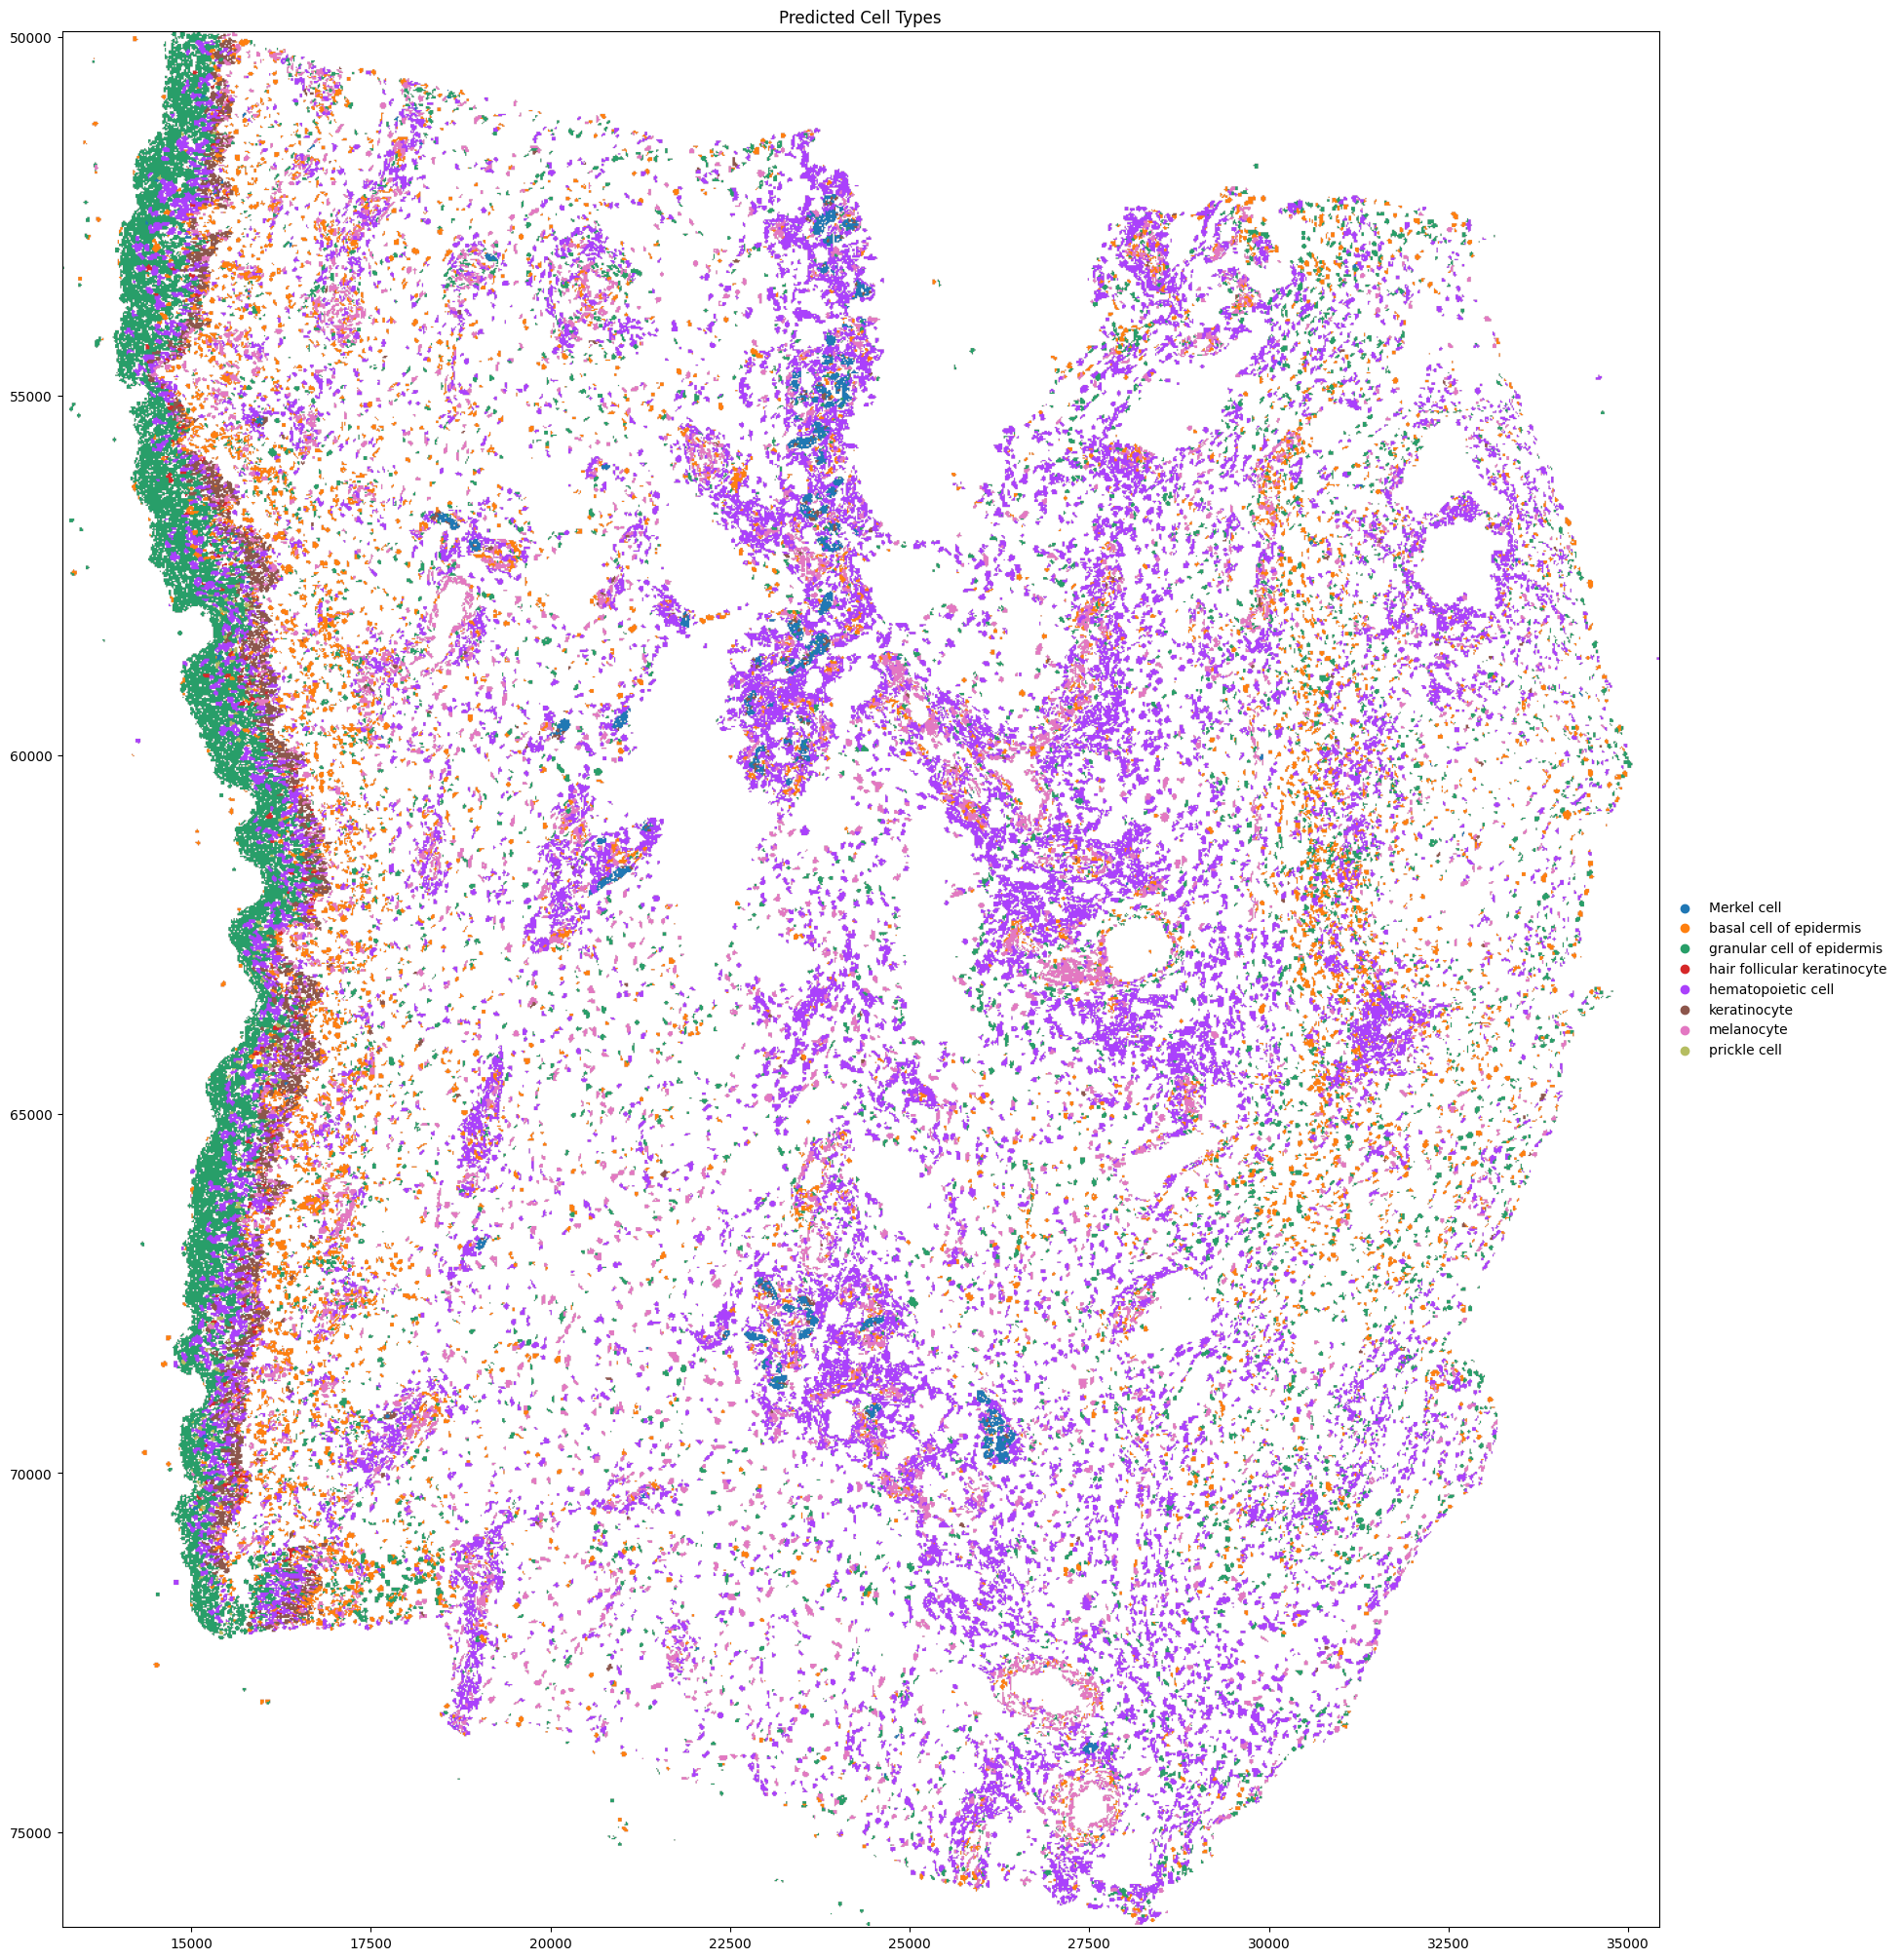

In [11]:
# 6. Save and Visualize (Final Data Integrity Fix)
# -----------------------------------------------
# The ValidationError indicates a mismatch between the table's 'region' column
# and the metadata. We will now fix the data itself to ensure it is valid.

# --- FIX 1: Align the table's region column with the shapes element ---
# We force every row in the table to explicitly state it belongs to 'cell_boundaries'.
# This is the most robust way to fix the data integrity issue.
print("Aligning table data with the 'cell_boundaries' shapes element...")
sdata.table.obs['region'] = 'cell_boundaries'
sdata.table.obs['region'] = sdata.table.obs['region'].astype('category')

# --- FIX 2: Set the complete and correct metadata ---
# Now that the data is clean, we set the metadata to match it perfectly.
print("Setting the final, validated metadata...")
sdata.table.uns['spatialdata_attrs'] = {
    'region': 'cell_boundaries',
    'region_key': 'region',
    'instance_key': 'cell_id'
}

# --- FIX 3: Ensure the color column is 'category' dtype ---
print("Ensuring the annotation column is the correct data type...")
sdata.table.obs['cell_type_predicted'] = sdata.table.obs['cell_type_predicted'].astype('category')

# --- Visualize using the official, chained plotting API ---
# With the data and metadata now fully validated, the plot will render.
print("Generating the final plot...")
# sdata.pl.render_images(
#     element="morphology_focus",
#     alpha=0.5
# )
sdata.pl.render_shapes(
    element="cell_boundaries",
    color="cell_type_predicted",
    legend_kwargs={"loc": "upper left", "bbox_to_anchor": (1, 1)},
    legend_fontsize=8
).pl.show(
    title="Predicted Cell Types",
    figsize=(20, 20)
)

NameError: name 'ljkl' is not defined